# Financial Behavior Intelligence System  
### Customer Segmentation, Anomaly Detection & Predictive Modeling

## Problem Statement
Financial institutions often struggle to understand customer behavior due to complex and high-volume transaction data. Identifying meaningful customer segments, detecting unusual activity, and predicting customer risk are critical for decision-making.

## Objective
This project analyzes financial transaction data by integrating multiple datasets to:
- Identify customer segments using clustering
- Detect anomalous financial behavior
- Build predictive models for customer classification

## Dataset
The dataset consists of multiple relational tables:
- FactTransaction
- DimAccount
- DimCustomer

This project aims to transform raw financial data into actionable insights for better decision-making.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

## Data Loading

In [2]:
fact_trans = pd.read_csv("../Dataset/FactTransaction.csv")
dim_acc = pd.read_csv("../Dataset/DimAccount.csv")
dim_cus = pd.read_csv("../Dataset/DimCustomer.csv")
dim_cus_us = pd.read_csv("../Dataset/DimCustomerUSA.csv")
dim_pro_cat = pd.read_csv("../Dataset/DimProductCategory.csv")
dim_pro_subcat = pd.read_csv("../Dataset/DimProductSubCategory.csv")

## Data Understanding

In [3]:
fact_trans.info()
fact_trans.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TransactionID       10000 non-null  int64  
 1   AccountID           10000 non-null  int64  
 2   TransactionDate     10000 non-null  object 
 3   TransactionAmount   10000 non-null  float64
 4   TransactionType     10000 non-null  object 
 5   TransactionChannel  10000 non-null  object 
 6   ProductID           10000 non-null  int64  
 7   Status              10000 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 625.1+ KB


(10000, 8)

### Observations:
- Dataset contains 10,000 transaction records
- Includes transaction details such as amount, type, and channel
- No missing values in key transaction fields

In [4]:
dim_cus.info()
dim_cus.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  100 non-null    int64 
 1   FullName    100 non-null    object
 2   DOB         100 non-null    object
 3   Gender      100 non-null    object
 4   Region      100 non-null    object
 5   Email       100 non-null    object
 6   Status      100 non-null    object
 7   JoinDate    100 non-null    object
dtypes: int64(1), object(7)
memory usage: 6.4+ KB


(100, 8)

### Observations:
- Contains customer demographic details
- Includes attributes such as age, gender, and region

In [5]:
dim_acc.info()
dim_acc.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AccountID       193 non-null    int64  
 1   CustomerID      193 non-null    int64  
 2   AccountType     193 non-null    object 
 3   OpenDate        193 non-null    object 
 4   ClosedDate      107 non-null    object 
 5   Status          193 non-null    object 
 6   RegistrationID  193 non-null    int64  
 7   Balance         193 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 12.2+ KB


(193, 8)

### Observations:
- Contains account-level information such as balance and account type
- Missing values present in ClosedDate

## Data Integration

Relevant datasets are merged to create a unified dataset for analysis. 

#### Data Relationship:
FactTransaction contains transaction-level data, which is linked to DimAccount using AccountID and further connected to DimCustomer using CustomerID.

These tables are joined to create a consolidated dataset.

In [6]:
fact_full = fact_trans.merge(dim_acc, on="AccountID")

In [7]:
# Rename to avoid column conflicts
dim_cus = dim_cus.rename(columns={"Status": "CustomerStatus"})

# Merge customer data
fact_full = fact_full.merge(dim_cus, on="CustomerID")

In [8]:
fact_full.shape

(10000, 22)

### Observations:
- Datasets successfully merged into a unified structure
- Combined transaction, account, and customer information available

## Data Cleaning & Preprocessing

In [9]:
# Rename status columns for clarity
fact_full = fact_full.rename(columns={
    "Status_x": "TransactionStatus",
    "Status_y": "AccountStatus",
    "Status": "CustomerStatus"
})

In [10]:
# Rename duplicate customer columns
fact_full = fact_full.rename(columns={
    'FullName_x': 'FullName',
    'DOB_x': 'DOB',
    'Gender_x': 'Gender',
    'Region_x': 'Region',
    'Email_x': 'Email',
    'JoinDate_x': 'JoinDate'
})

In [11]:
# Remove duplicate columns after merge
fact_full = fact_full.loc[:, ~fact_full.columns.duplicated()]

In [12]:
fact_full.isnull().sum()

TransactionID            0
AccountID                0
TransactionDate          0
TransactionAmount        0
TransactionType          0
TransactionChannel       0
ProductID                0
TransactionStatus        0
CustomerID               0
AccountType              0
OpenDate                 0
ClosedDate            4500
AccountStatus            0
RegistrationID           0
Balance                  0
FullName                 0
DOB                      0
Gender                   0
Region                   0
Email                    0
CustomerStatus           0
JoinDate                 0
dtype: int64

### Observations:
- `ClosedDate` contains null values representing active accounts
- No significant missing values in other fields

In [13]:
fact_full.duplicated().sum()

np.int64(0)

### Observations:
- No duplicate records found
- Data integrity maintained after merging

## Exploratory Data Analysis

In [14]:
channel_analysis = fact_full.groupby("TransactionChannel")["TransactionAmount"].agg(["count","sum","mean"])
channel_analysis

,count,sum,mean
TransactionChannel,,,
ATM,1966,1163278.08,591.697904
Mobile,5044,2402181.27,476.245295
Web,2990,1658878.21,554.808766


### Insights:
- Mobile transactions have the highest volume, indicating strong adoption of mobile banking
- ATM transactions have the highest average value, suggesting usage for larger withdrawals
- Web transactions show moderate usage with relatively high transaction values

In [15]:
account_analysis = fact_full.groupby("AccountType")["TransactionAmount"].agg(["count","sum","mean"])
account_analysis

,count,sum,mean
AccountType,,,
Checking,3707,2043855.03,551.350156
Credit,2933,1696320.61,578.356839
Savings,3360,1484161.92,441.714857


### Insights:
- Checking accounts show the highest transaction activity
- Credit accounts have the highest average transaction value
- Savings accounts have lower transaction values, indicating conservative usage

In [16]:
status_analysis = fact_full.groupby("CustomerStatus")["TransactionAmount"].agg(["count","sum","mean"])
status_analysis

,count,sum,mean
CustomerStatus,,,
Active,3769,1941450.13,515.110143
Inactive,2715,1287371.11,474.169838
Suspended,3516,1995516.32,567.552992


### Insights:
- Suspended customers show the highest average transaction values, indicating irregular activity
- Active customers have consistent and moderate transaction behavior
- Inactive customers show lower engagement and transaction values

## Time-Based Analysis

In [17]:
# Convert date columns to datetime
fact_full["TransactionDate"] = pd.to_datetime(fact_full["TransactionDate"])
fact_full["DOB"] = pd.to_datetime(fact_full["DOB"], format="%d/%m/%Y")
fact_full["JoinDate"] = pd.to_datetime(fact_full["JoinDate"], format="%d/%m/%Y")
fact_full["OpenDate"] = pd.to_datetime(fact_full["OpenDate"])
fact_full["ClosedDate"] = pd.to_datetime(fact_full["ClosedDate"])

# Extract time-based features
fact_full["Year"] = fact_full["TransactionDate"].dt.year
fact_full["Month"] = fact_full["TransactionDate"].dt.month
fact_full["DayOfWeek"] = fact_full["TransactionDate"].dt.day_name()

In [18]:
year_analysis = fact_full.groupby("Year")["TransactionAmount"].agg(["count","sum","mean"])
year_analysis

,count,sum,mean
Year,,,
2020,1684,701542.14,416.592720
2021,1681,887031.78,527.681011
2022,1649,878532.74,532.766974
2023,1654,914758.54,553.058368
2024,1650,618482.00,374.837576
2025,1682,1223990.36,727.699382


### Insights:
- Transaction activity increases from 2020 to 2023, indicating growing engagement
- A drop in 2024 may indicate incomplete data or reduced activity
- 2025 shows a sharp rise in average transaction value, suggesting higher-value transactions

In [19]:
month_analysis = fact_full.groupby("Month")["TransactionAmount"].mean()
month_analysis

Month
1     518.679734
2     573.980406
3     494.887810
4     476.461909
5     537.282068
6     402.960874
7     562.833865
8     523.051496
9     464.704304
10    655.711101
11    419.653927
12    634.760450
Name: TransactionAmount, dtype: float64

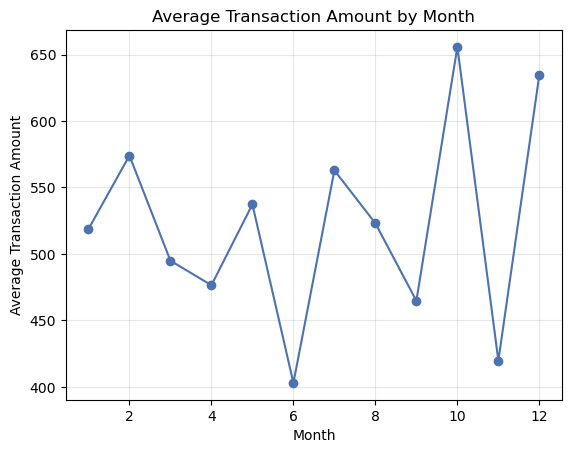

In [20]:
month_analysis.plot(kind='line', marker='o', color='#4C72B0')
plt.title("Average Transaction Amount by Month")
plt.xlabel("Month")
plt.ylabel("Average Transaction Amount")
plt.grid(alpha=0.3)
plt.show()

### Insights:
- October and December show peak transaction values, likely due to festive spending
- Mid-year months like June show lower activity
- Clear seasonal variation is observed in customer spending

In [21]:
day_analysis = fact_full.groupby("DayOfWeek")["TransactionAmount"].mean()

day_analysis = day_analysis.reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

day_analysis

DayOfWeek
Monday       386.560417
Tuesday      560.843621
Wednesday    514.898131
Thursday     614.811984
Friday       488.289695
Saturday     571.820749
Sunday       515.781734
Name: TransactionAmount, dtype: float64

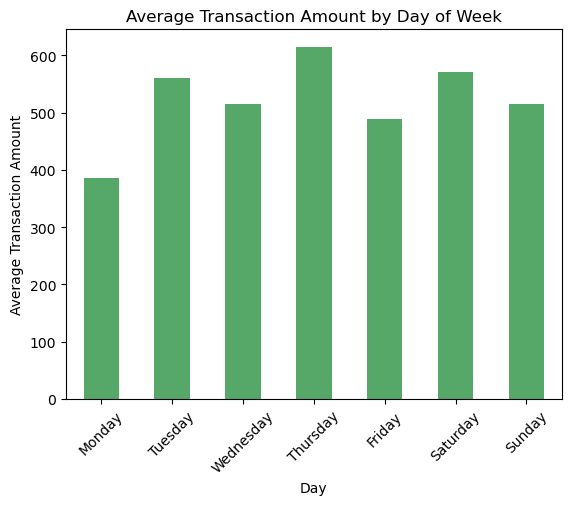

In [22]:
day_analysis.plot(kind='bar',color='#55A868')
plt.title("Average Transaction Amount by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=45)
plt.show()

### Insights:
- Thursday shows the highest transaction values, indicating peak activity toward the weekend
- Saturday and Tuesday also show higher spending
- Monday has the lowest activity, indicating a slow start to the week

## Feature Engineering

### Transaction Value Convention:
- Debit transactions are positive (outflow)
- Credit transactions are negative (inflow)

This convention is used to compute net transaction behavior.

### Customer-Level Feature Creation:
Transaction-level data is aggregated to generate customer-level features capturing transaction frequency, spending behavior, and financial patterns.

In [23]:
# Aggregate transaction-level data
customer_df = fact_full.groupby("CustomerID").agg({
    "TransactionID": "count",
    "TransactionAmount": ["sum", "mean", "std"],
    "Balance": "mean"
})

# Flatten column names
customer_df.columns = [
    "TransactionID_count",
    "TransactionAmount_sum",
    "TransactionAmount_mean",
    "TransactionAmount_std",
    "Balance_mean"
]

customer_df = customer_df.reset_index()

# Channel usage per customer
channel_counts = fact_full.pivot_table(
    index="CustomerID",
    columns="TransactionChannel",
    values="TransactionID",
    aggfunc="count",
    fill_value=0
).reset_index()

# Merge with main dataframe
customer_df = customer_df.merge(channel_counts, on="CustomerID")

### Channel Behavior Feature:
Average transactions per channel is computed to capture customer interaction intensity across different platforms.

In [24]:
# Average transactions per channel
customer_df["Avg_Transactions_Per_Channel"] = (
    customer_df[["ATM", "Mobile", "Web"]].sum(axis=1) / 3
)

### Adding Customer Demographics:
Customer attributes such as gender, status, and age are incorporated to enhance behavioral analysis.

In [25]:
# Extract static customer attributes
customer_info = fact_full.groupby("CustomerID").agg({
    "Gender": "first",
    "CustomerStatus": "first",
    "DOB": "first"
}).reset_index()

In [26]:
# Calculate age
customer_info["Age"] = (pd.Timestamp.now() - customer_info["DOB"]).dt.days // 365

customer_info = customer_info.drop(columns=["DOB"])

# Merge with main dataframe
customer_df = customer_df.merge(customer_info, on="CustomerID")

In [27]:
# Net transaction amount per customer
customer_df["Net_Amount"] = customer_df["TransactionAmount_sum"]

### Feature Summary:
The dataset now contains customer-level features capturing:
- Transaction frequency and variability
- Financial behavior and net activity
- Channel usage patterns
- Customer demographics

These features form the foundation for segmentation, anomaly detection, and predictive modeling.

## Customer Segmentation (Clustering)

### Feature Selection:
Selected features represent transaction behavior, financial activity, channel usage, and demographics for effective segmentation.

In [28]:
# Features selected for clustering (behavioral + demographic)
features = customer_df[[
    "TransactionID_count",
    "TransactionAmount_mean",
    "TransactionAmount_std",
    "Balance_mean",
    "Net_Amount",
    "ATM",
    "Mobile",
    "Web",
    "Age"
]]

In [29]:
# Standardize features for clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### Optimal Cluster Selection:
The Elbow Method is used to determine the appropriate number of clusters by analyzing WCSS.

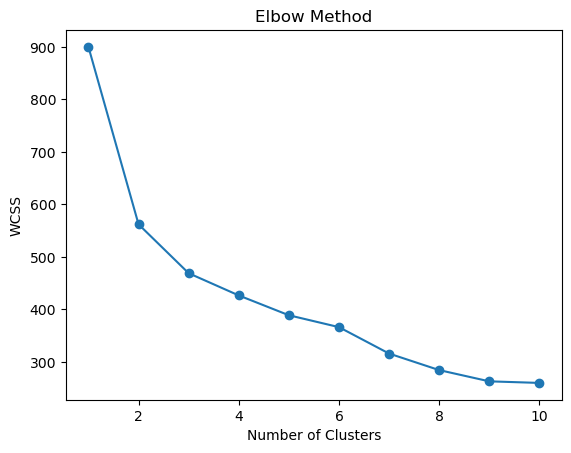

In [30]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Applying KMeans:
Based on the Elbow Method, 3 clusters are selected to segment customers into distinct behavioral groups.

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_df["Cluster"] = kmeans.fit_predict(scaled_features)

In [32]:
customer_df["Cluster"].value_counts()

Cluster
1    39
0    35
2    26
Name: count, dtype: int64

### Observations:
The dataset is reasonably distributed across clusters, indicating meaningful segmentation without extreme imbalance.

In [33]:
cluster_summary = customer_df.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,CustomerID,TransactionID_count,TransactionAmount_sum,TransactionAmount_mean,TransactionAmount_std,Balance_mean,ATM,Mobile,Web,Avg_Transactions_Per_Channel,Age,Net_Amount
Cluster,,,,,,,,,,,,
0,44.628571,70.200000,50946.624000,727.134547,2707.770075,14034.475825,14.400000,34.828571,20.971429,23.400000,43.857143,50946.624000
1,56.692308,149.717949,80800.973077,543.469675,2838.455788,16782.042358,29.512821,75.435897,44.769231,49.905983,39.717949,80800.973077
2,49.115385,65.538462,11152.606538,136.064099,2996.938276,18906.128605,11.961538,33.961538,19.615385,21.846154,43.500000,11152.606538


### Cluster Profiling:
Cluster-wise averages are analyzed to understand behavioral differences between customer segments.

#### Cluster Interpretation:
- Cluster 0: Moderate transaction activity and balanced behavior → Regular Customers
- Cluster 1: High transaction volume and high spending → High Value Customers
- Cluster 2: Low transaction activity and lower spending → Low Activity Customers

In [34]:
# Assign labels
cluster_labels = {
    0: "Regular Customers",
    1: "High Value Customers",
    2: "Low Activity Customers"
}

customer_df["Cluster_Label"] = customer_df["Cluster"].map(cluster_labels)

In [35]:
customer_df["Cluster_Label"].value_counts()

Cluster_Label
High Value Customers      39
Regular Customers         35
Low Activity Customers    26
Name: count, dtype: int64

## Anomaly Detection

In [36]:
# Features selected for anomaly detection (behavior + financial variability)
anomaly_features = customer_df[[
    "TransactionID_count",
    "TransactionAmount_mean",
    "TransactionAmount_std",
    "Balance_mean",
    "Net_Amount"
]]

In [37]:
scaler = StandardScaler()
scaled_anomaly = scaler.fit_transform(anomaly_features)

In [38]:
# Apply Isolation Forest (5% contamination assumed)
iso = IsolationForest(contamination=0.05, random_state=42)
customer_df["Anomaly"] = iso.fit_predict(scaled_anomaly)

#### Note:
Isolation Forest labels anomalies as -1 and normal observations as 1.

In [39]:
customer_df["Anomaly"].value_counts()

Anomaly
 1    95
-1     5
Name: count, dtype: int64

In [40]:
anomalies = customer_df[customer_df["Anomaly"] == -1]
anomalies.head()

,CustomerID,TransactionID_count,TransactionAmount_sum,TransactionAmount_mean,TransactionAmount_std,Balance_mean,ATM,Mobile,Web,Avg_Transactions_Per_Channel,Gender,CustomerStatus,Age,Net_Amount,Cluster,Cluster_Label,Anomaly
5,6,53,6927.68,130.710943,2441.853617,34979.760000,7,23,23,17.666667,Female,Inactive,29,6927.68,0,Regular Customers,-1
15,16,166,155082.64,934.232771,2982.017080,17715.333675,29,87,50,55.333333,Female,Active,29,155082.64,1,High Value Customers,-1
24,25,49,-25128.28,-512.822041,3028.265523,31498.310000,7,28,14,16.333333,Male,Active,63,-25128.28,2,Low Activity Customers,-1
43,44,46,-31062.19,-675.265000,2851.470509,8565.360000,8,26,12,15.333333,Male,Inactive,61,-31062.19,2,Low Activity Customers,-1
90,91,58,3775.32,65.091724,3015.831514,48604.660000,9,27,22,19.333333,Male,Active,50,3775.32,2,Low Activity Customers,-1


### Insights:
- Approximately 5% of customers are identified as anomalies
- These customers show unusual or extreme financial behavior
- Such patterns may indicate potential fraud, risk, or outlier activity

Anomaly detection helps highlight customers requiring further investigation.

## Predictive Modeling (Multiclass Classification)

### Objective:
Predict customer segment (cluster) using behavioral and demographic features.

In [41]:
# Features for prediction
X = customer_df[[
    "TransactionID_count",
    "Balance_mean",
    "ATM",
    "Mobile",
    "Web",
    "Age"
]]

# Target variable (cluster labels)
y = customer_df["Cluster"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# Train XGBoost classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [44]:
accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.44      0.50      0.47         8
           1       1.00      1.00      1.00         5
           2       0.33      0.29      0.31         7

    accuracy                           0.55        20
   macro avg       0.59      0.60      0.59        20
weighted avg       0.54      0.55      0.55        20



array([[4, 0, 4],
       [0, 5, 0],
       [5, 0, 2]])

### Insights:
- The model achieves moderate accuracy (~55%), indicating realistic performance
- High-value customers are easier to classify due to distinct behavior
- Overlap between clusters leads to misclassification

This task is inherently challenging due to overlapping customer behavior patterns.

#### Note:
Clusters are generated using unsupervised learning, so predicting them using supervised models has inherent limitations.

## Binary Classification: High-Value Customer Prediction

Customers are classified into:
- High Value Customers (1)
- Others (0)

This simplifies prediction and improves business usability.

In [45]:
customer_df["High_Value_Flag"] = (customer_df["Cluster_Label"] == "High Value Customers").astype(int)

# Features for binary classification
X = customer_df[[
    "TransactionID_count",
    "Balance_mean",
    "ATM",
    "Mobile",
    "Web",
    "Age"
]]

y = customer_df["High_Value_Flag"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [47]:
accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.80      0.89         5

    accuracy                           0.95        20
   macro avg       0.97      0.90      0.93        20
weighted avg       0.95      0.95      0.95        20



array([[15,  0],
       [ 1,  4]])

In [48]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
4,Web,0.131343
0,TransactionID_count,0.046982
3,Mobile,0.005039
1,Balance_mean,-0.000041
2,ATM,-0.089400
5,Age,-0.166731


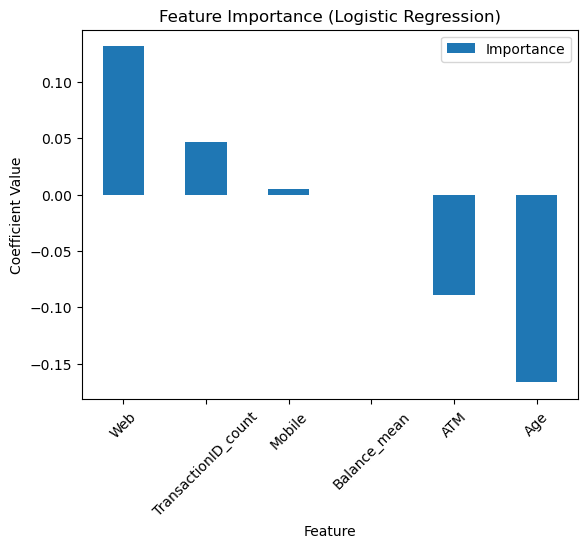

In [49]:
feature_importance.set_index("Feature").plot(kind="bar")
plt.title("Feature Importance (Logistic Regression)")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.show()

#### Feature Importance Insights:

1. Web transactions have the highest positive impact, indicating that customers using web channels are more likely to be high-value  
2. Transaction frequency also contributes positively, suggesting active users tend to be more valuable  
3. Mobile usage has minimal impact, indicating it is common across all customer types  

4. Age has the strongest negative impact, indicating younger customers are more likely to be high-value  
5. ATM usage negatively impacts prediction, suggesting high-value customers rely less on ATM transactions  
6. Balance_mean has negligible influence on classification  

Overall, channel behavior and transaction activity are stronger predictors of customer value than static financial attributes.

### Insights:
- High accuracy (~95%) indicates strong separation between high-value and other customers
- Binary classification simplifies the learning problem
- Results may be slightly optimistic due to dataset size and class distribution

This model is effective for identifying high-value customers for targeted strategies.

## Model Summary & Comparison

This section summarizes the performance of all models used in the project.

| Model Type | Algorithm | Purpose | Performance |
|------------|----------|--------|------------|
| Clustering | KMeans | Customer Segmentation | Meaningful clusters |
| Anomaly Detection | Isolation Forest | Detect unusual behavior | ~5% anomalies |
| Classification (Multiclass) | XGBoost | Predict segments | ~55% accuracy |
| Classification (Binary) | Logistic Regression | Predict high-value customers | ~95% accuracy |

### Key Observations:
- Unsupervised models provide strong behavioral insights
- Multiclass classification is challenging due to overlapping patterns
- Binary classification performs significantly better due to simplified structure
- Models serve complementary purposes rather than direct comparison

## Final Conclusion

This project demonstrates how financial transaction data can be transformed into actionable insights using a combination of data analysis and machine learning techniques.

- Customer segmentation using clustering revealed distinct behavioral groups such as high-value, regular, and low-activity customers
- Anomaly detection identified a small subset of customers with unusual financial patterns, supporting risk monitoring and fraud detection
- Predictive modeling highlighted the challenges of multiclass classification due to overlapping behaviors, while binary classification proved effective for identifying high-value customers

Feature importance analysis further showed that digital channel usage and transaction activity are key drivers of customer value, reflecting a shift toward digital-first financial behavior.

Overall, this project showcases an end-to-end data science workflow, combining data preprocessing, feature engineering, unsupervised learning, and predictive modeling to support data-driven decision-making in financial systems.